In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Seaborn optional tapi direkomendasikan
import seaborn as sns
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

print("Imports & settings ready ")

Imports & settings ready 


In [4]:
def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=labels, yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_decision_boundary_binary(model, X, y, scaler, xlabel, ylabel, title):
    """
    Untuk binary classification, X harus 2 fitur.
    model dilatih pada data yang sudah discale.
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    Z = model.predict(grid_scaled).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

TUGAS 1 — Breast Cancer (Binary) (30 poin)

In [5]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X = bc.data
y = bc.target
feature_names = bc.feature_names
target_names = bc.target_names

df_bc = pd.DataFrame(X, columns=feature_names)
df_bc["target"] = y

print("Shape:", df_bc.shape)
print("Target names:", target_names)
print("\nClass distribution:\n", df_bc["target"].value_counts())
df_bc.head()

Shape: (569, 31)
Target names: ['malignant' 'benign']

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (455, 30) Test: (114, 30)


In [7]:
lr_bc = LogisticRegression(max_iter=10000, random_state=42)
lr_bc.fit(X_train_scaled, y_train)

y_pred = lr_bc.predict(X_test_scaled)
y_proba = lr_bc.predict_proba(X_test_scaled)[:, 1]

print("Model trained ✅")

Model trained ✅


In [8]:
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print("=== Tugas 1: Logistic Regression (Breast Cancer) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

=== Tugas 1: Logistic Regression (Breast Cancer) ===
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



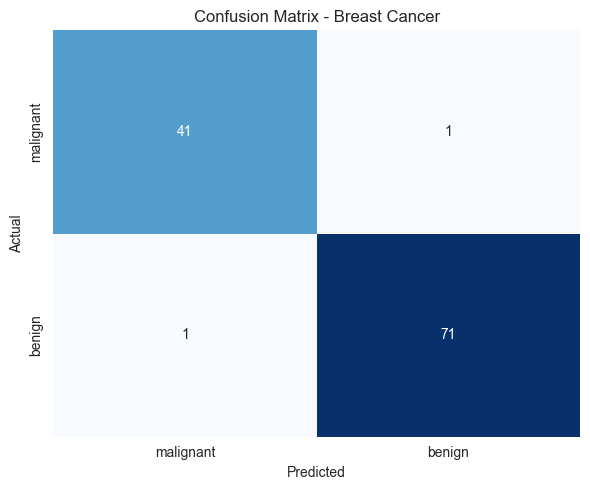

In [9]:
cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, labels=target_names, title="Confusion Matrix - Breast Cancer")

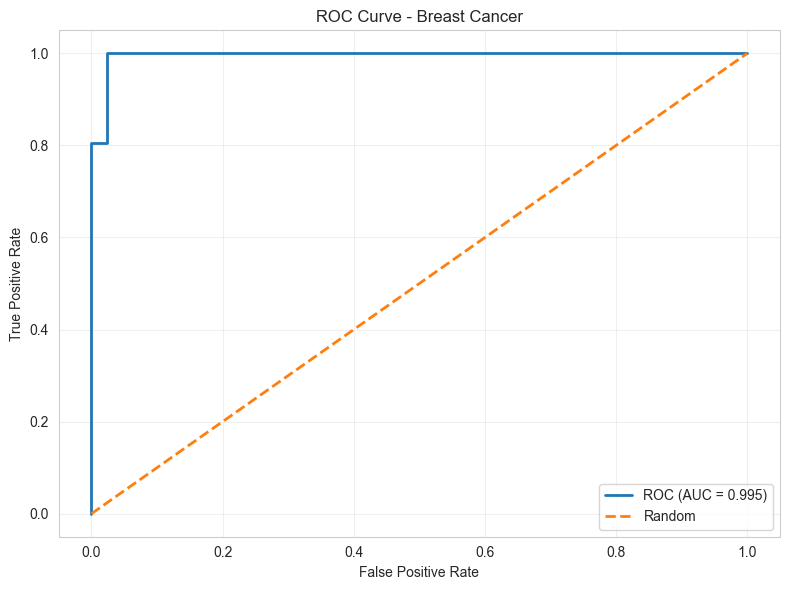

AUC: 0.9953703703703703


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Breast Cancer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC:", roc_auc)

In [11]:
# Korelasi hanya numeric (aman, tidak akan error)
corr_target = df_bc.select_dtypes(include="number").corr()["target"].abs().sort_values(ascending=False)
top2 = corr_target.index[1:3].tolist()  # exclude 'target'
print("Top 2 features:", top2)

X2 = df_bc[top2].values
y2 = df_bc["target"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

lr_bc_2f = LogisticRegression(max_iter=10000, random_state=42)
lr_bc_2f.fit(X2_train_scaled, y2_train)

print("2-feature model trained ✅")

Top 2 features: ['worst concave points', 'worst perimeter']
2-feature model trained ✅


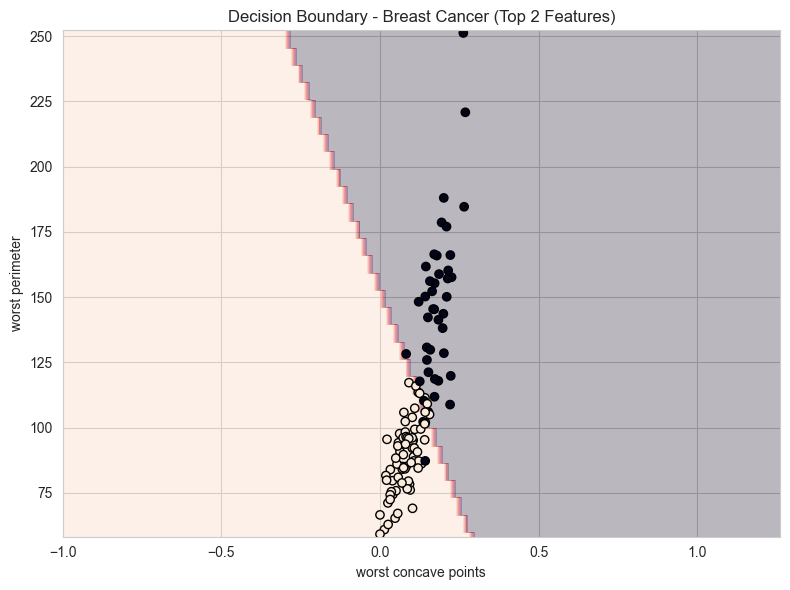

In [12]:
plot_decision_boundary_binary(
    lr_bc_2f, X2_test, y2_test, scaler2,
    xlabel=top2[0], ylabel=top2[1],
    title="Decision Boundary - Breast Cancer (Top 2 Features)"
)

In [13]:
print("=== Interpretasi Tugas 1 (Ringkas) ===")
print("- Pada diagnosis kanker, Recall (sensitivitas) biasanya lebih penting daripada Precision.")
print("- Karena False Negative (kanker diprediksi sehat) berisiko fatal.")
print("- Model yang baik untuk medis harus meminimalkan kasus kanker yang terlewat.")

=== Interpretasi Tugas 1 (Ringkas) ===
- Pada diagnosis kanker, Recall (sensitivitas) biasanya lebih penting daripada Precision.
- Karena False Negative (kanker diprediksi sehat) berisiko fatal.
- Model yang baik untuk medis harus meminimalkan kasus kanker yang terlewat.


TUGAS 2 — Wine Dataset (Multi-class) (35 poin)

In [14]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df_wine = pd.DataFrame(X, columns=feature_names)
df_wine["target"] = y
df_wine["class"] = df_wine["target"].map({i: target_names[i] for i in range(len(target_names))})

print("Shape:", df_wine.shape)
print("\nClass distribution:\n", df_wine["class"].value_counts())
df_wine.head()

Shape: (178, 15)

Class distribution:
 class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


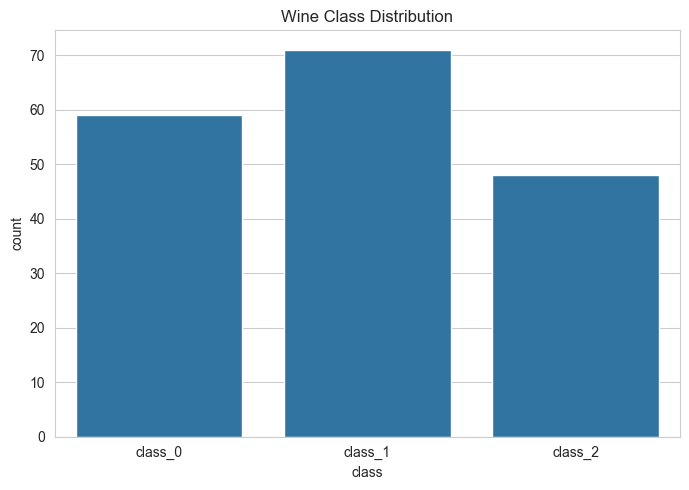

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(x="class", data=df_wine)
plt.title("Wine Class Distribution")
plt.tight_layout()
plt.show()

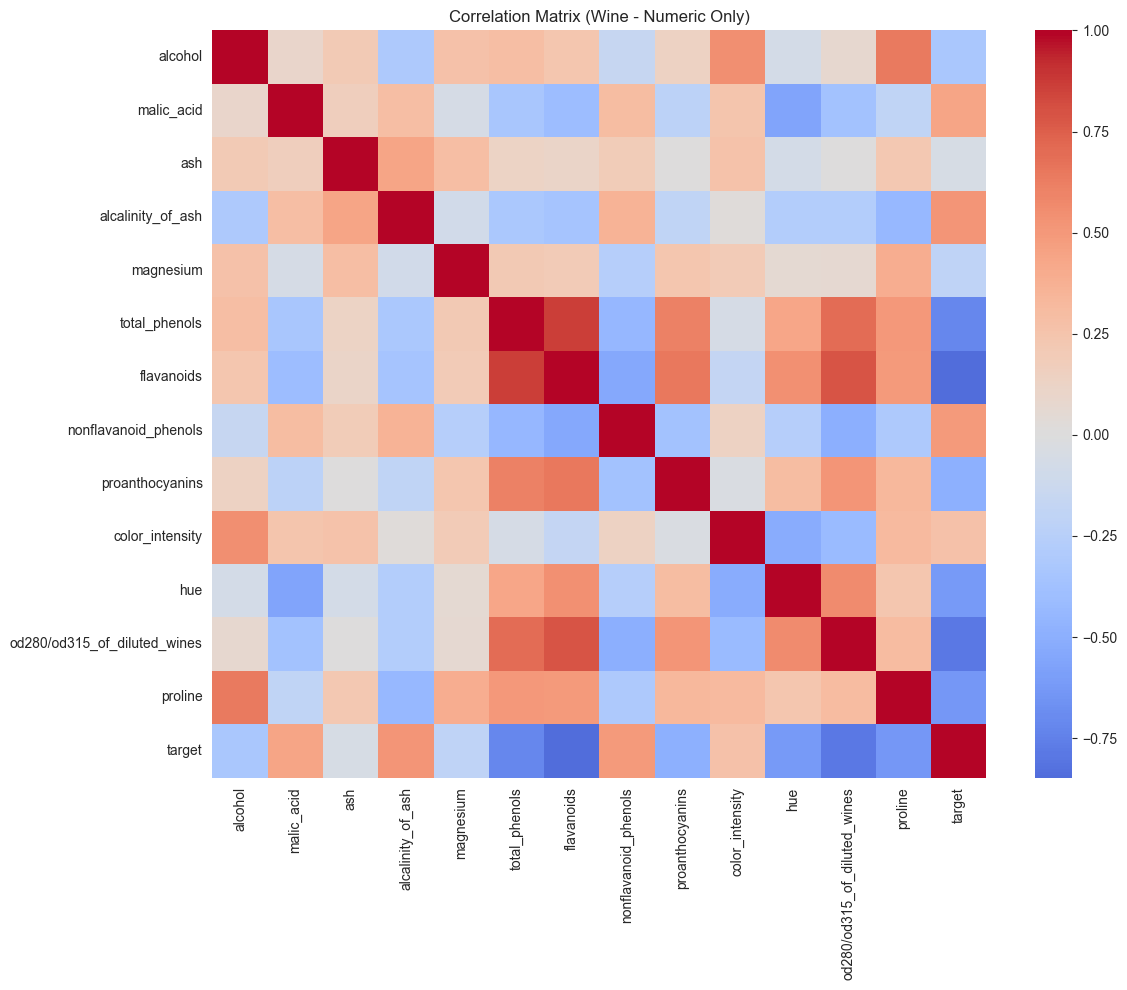

In [16]:
plt.figure(figsize=(12, 10))
corr_mat = df_wine.select_dtypes(include="number").corr()
sns.heatmap(corr_mat, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Wine - Numeric Only)")
plt.tight_layout()
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

=== Tugas 2: Logistic Regression (Wine) ===
Accuracy: 0.9722222222222222

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



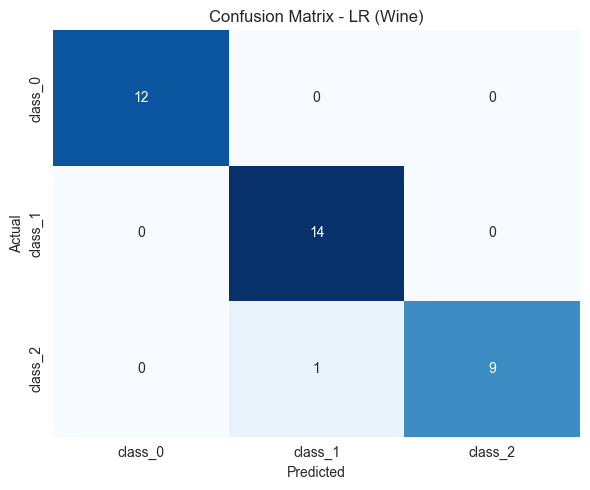

In [18]:
lr_wine = LogisticRegression(max_iter=10000, random_state=42)
lr_wine.fit(X_train_scaled, y_train)

pred_lr = lr_wine.predict(X_test_scaled)

print("=== Tugas 2: Logistic Regression (Wine) ===")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr, target_names=target_names))

cm_lr = confusion_matrix(y_test, pred_lr)
plot_confusion_matrix(cm_lr, labels=target_names, title="Confusion Matrix - LR (Wine)")

=== Tugas 2: Decision Tree (Wine) ===
Accuracy: 0.9444444444444444

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



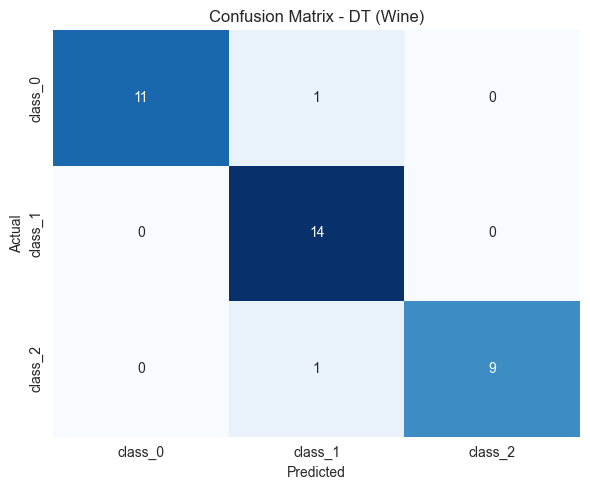

In [19]:
dt_wine = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_wine.fit(X_train, y_train)

pred_dt = dt_wine.predict(X_test)

print("=== Tugas 2: Decision Tree (Wine) ===")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_dt, target_names=target_names))

cm_dt = confusion_matrix(y_test, pred_dt)
plot_confusion_matrix(cm_dt, labels=target_names, title="Confusion Matrix - DT (Wine)")

In [20]:
comparison_wine = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt)
    ],
    "Precision (weighted)": [
        precision_score(y_test, pred_lr, average="weighted"),
        precision_score(y_test, pred_dt, average="weighted")
    ],
    "Recall (weighted)": [
        recall_score(y_test, pred_lr, average="weighted"),
        recall_score(y_test, pred_dt, average="weighted")
    ],
    "F1 (weighted)": [
        f1_score(y_test, pred_lr, average="weighted"),
        f1_score(y_test, pred_dt, average="weighted")
    ]
})

comparison_wine

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,Logistic Regression,0.972222,0.974074,0.972222,0.971970
1,Decision Tree,0.944444,0.951389,0.944444,0.944961


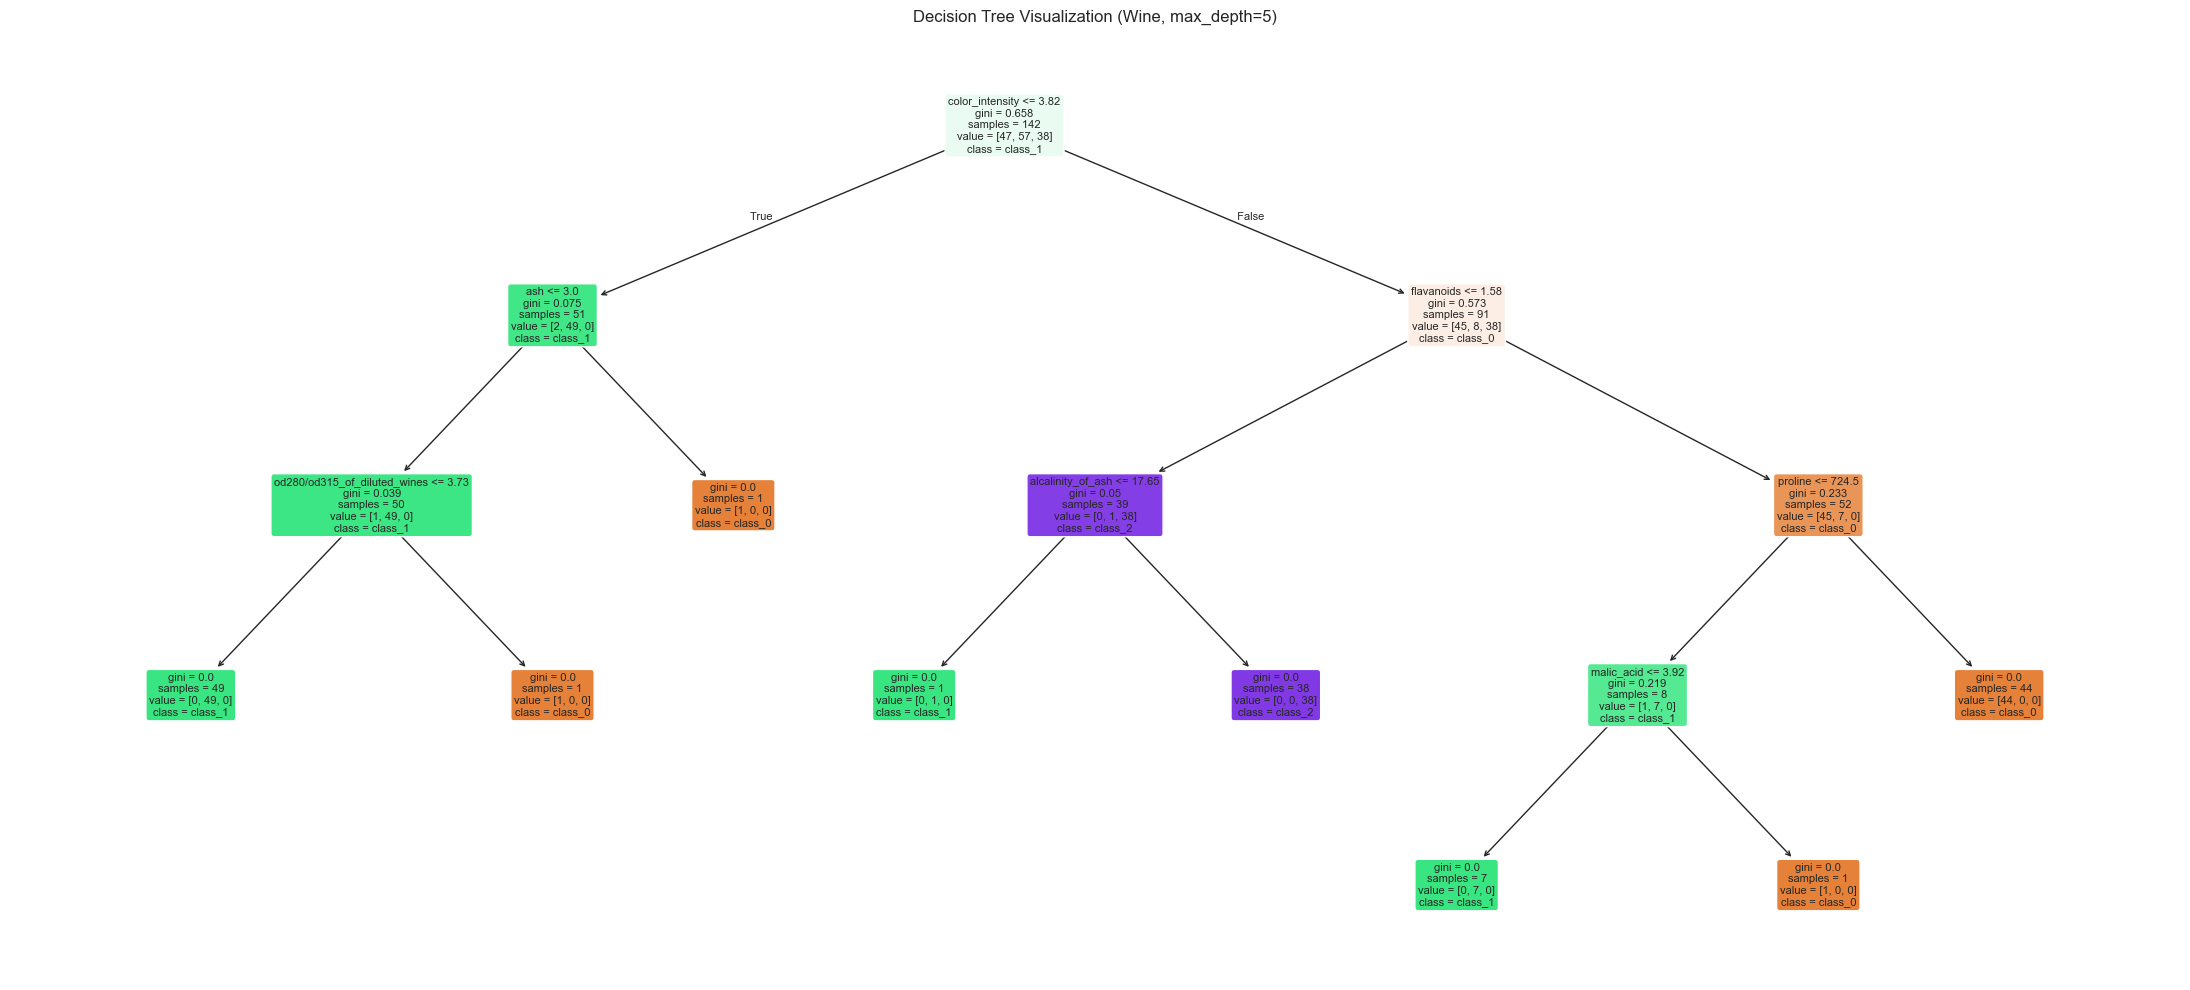

In [21]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_wine,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (Wine, max_depth=5)")
plt.tight_layout()
plt.show()

In [22]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_wine.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
6,flavanoids,0.408073
9,color_intensity,0.400189
12,proline,0.110985
11,od280/od315_of_diluted_wines,0.020986
3,alcalinity_of_ash,0.020865
2,ash,0.020163
1,malic_acid,0.018738
4,magnesium,0.000000
0,alcohol,0.000000
8,proanthocyanins,0.000000


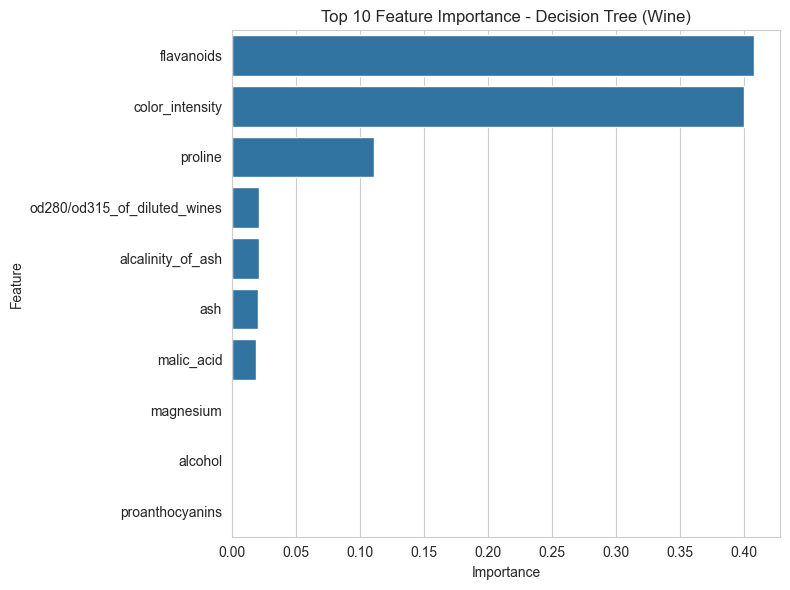

In [23]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importance - Decision Tree (Wine)")
plt.tight_layout()
plt.show()

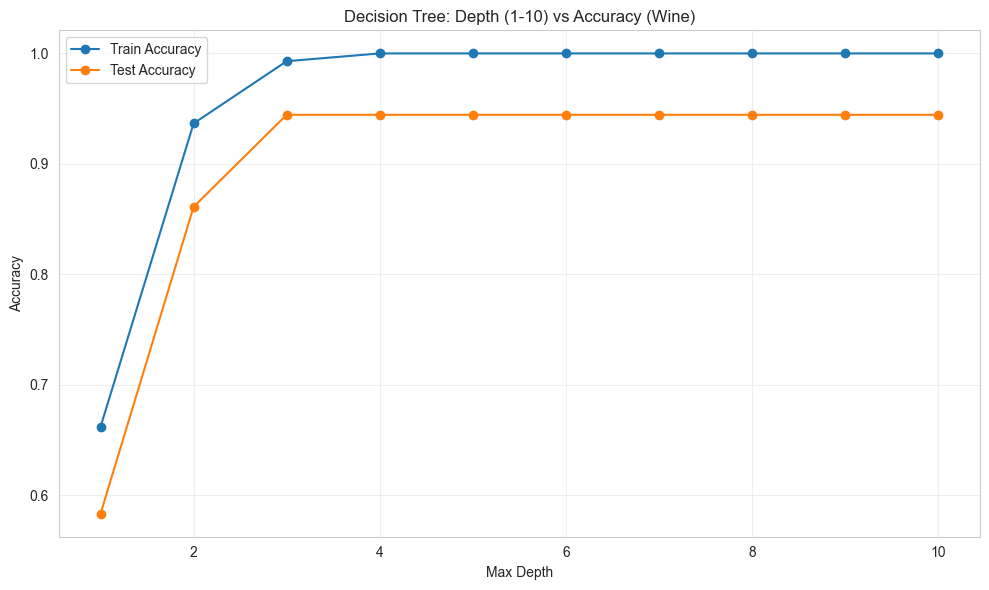

Best depth (1-10): 3
Best test accuracy: 0.9444444444444444


In [24]:
depths = range(1, 11)
train_scores = []
test_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Depth (1-10) vs Accuracy (Wine)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_depth_1_10 = list(depths)[int(np.argmax(test_scores))]
print("Best depth (1-10):", best_depth_1_10)
print("Best test accuracy:", float(np.max(test_scores)))

In [25]:
best_lr = accuracy_score(y_test, pred_lr)
best_dt = accuracy_score(y_test, pred_dt)

print("=== Kesimpulan Tugas 2 (Ringkas) ===")
print(f"- Logistic Regression accuracy: {best_lr:.4f}")
print(f"- Decision Tree accuracy     : {best_dt:.4f}")
print("- LR cenderung lebih stabil (setelah scaling).")
print("- DT interpretatif (tree & feature importance), tapi lebih rawan overfitting jika depth besar.")

=== Kesimpulan Tugas 2 (Ringkas) ===
- Logistic Regression accuracy: 0.9722
- Decision Tree accuracy     : 0.9444
- LR cenderung lebih stabil (setelah scaling).
- DT interpretatif (tree & feature importance), tapi lebih rawan overfitting jika depth besar.


TUGAS 3 — Overfitting Analysis (Wine) (20 poin)

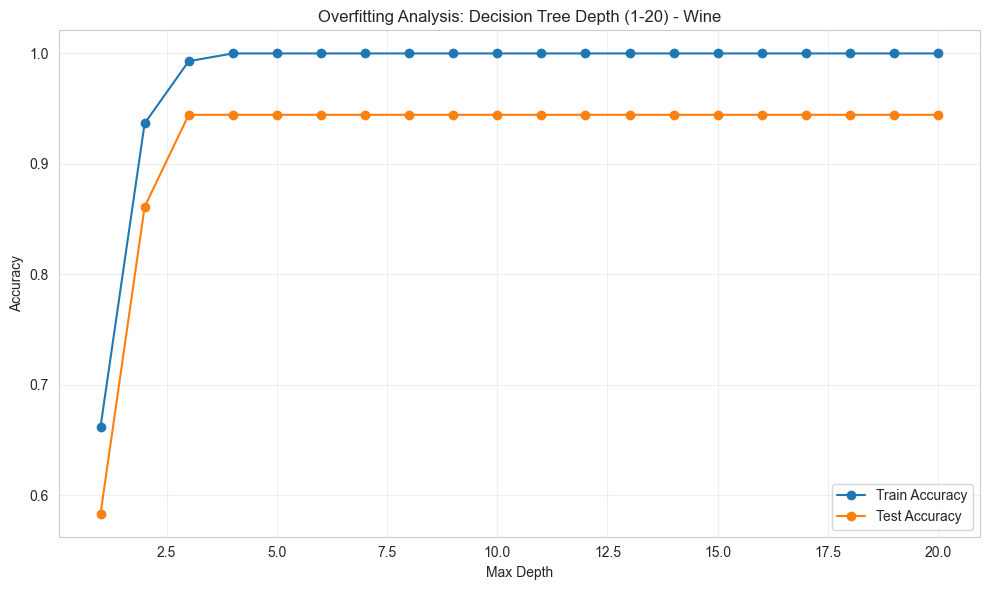

Best depth (1-20): 3
Best test accuracy: 0.9444444444444444


In [26]:
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Decision Tree Depth (1-20) - Wine")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_depth_1_20 = list(depths)[int(np.argmax(test_scores))]
print("Best depth (1-20):", best_depth_1_20)
print("Best test accuracy:", float(np.max(test_scores)))

In [27]:
# Indikasi overfitting: train naik terus, test mulai turun/stagnan
gap = np.array(train_scores) - np.array(test_scores)

summary_df = pd.DataFrame({
    "max_depth": list(depths),
    "train_acc": train_scores,
    "test_acc": test_scores,
    "gap(train-test)": gap
})

summary_df.head(10)

,max_depth,train_acc,test_acc,gap(train-test)
0,1,0.661972,0.583333,0.078638
1,2,0.936620,0.861111,0.075509
2,3,0.992958,0.944444,0.048513
3,4,1.000000,0.944444,0.055556
4,5,1.000000,0.944444,0.055556
5,6,1.000000,0.944444,0.055556
6,7,1.000000,0.944444,0.055556
7,8,1.000000,0.944444,0.055556
8,9,1.000000,0.944444,0.055556
9,10,1.000000,0.944444,0.055556


In [28]:
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc  = accuracy_score(y_test, lr.predict(X_test_scaled))

print("=== Logistic Regression Baseline (Wine, Scaled) ===")
print("Train Accuracy:", lr_train_acc)
print("Test Accuracy :", lr_test_acc)

=== Logistic Regression Baseline (Wine, Scaled) ===
Train Accuracy: 1.0
Test Accuracy : 0.9722222222222222


In [29]:
print("=== Penjelasan Tugas 3 (Ringkas) ===")
print("- Decision Tree bisa membentuk aturan yang sangat kompleks saat depth besar, sehingga mudah 'menghafal' data training.")
print("- Ini meningkatkan variance: train accuracy tinggi, tetapi test bisa turun (overfitting).")
print("- Logistic Regression lebih 'terbatas' (model linear) dan biasanya lebih stabil setelah scaling.")

=== Penjelasan Tugas 3 (Ringkas) ===
- Decision Tree bisa membentuk aturan yang sangat kompleks saat depth besar, sehingga mudah 'menghafal' data training.
- Ini meningkatkan variance: train accuracy tinggi, tetapi test bisa turun (overfitting).
- Logistic Regression lebih 'terbatas' (model linear) dan biasanya lebih stabil setelah scaling.


TUGAS 4 — Custom Dataset (Titanic) (15 poin)

In [30]:
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [31]:
df_t = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
df_t.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [32]:
df_t["age"] = df_t["age"].fillna(df_t["age"].median())
df_t["embarked"] = df_t["embarked"].fillna(df_t["embarked"].mode()[0])

df_t.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

In [33]:
df_t_enc = pd.get_dummies(df_t, drop_first=True)
df_t_enc.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [34]:
X = df_t_enc.drop("survived", axis=1)
y = df_t_enc["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (712, 8) Test: (179, 8)


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [36]:
lr_titanic = LogisticRegression(max_iter=10000, random_state=42)
lr_titanic.fit(X_train_scaled, y_train)

pred_lr = lr_titanic.predict(X_test_scaled)

print("=== Tugas 4: Logistic Regression (Titanic) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test, pred_lr):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr))

=== Tugas 4: Logistic Regression (Titanic) ===
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-Score : 0.7244

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



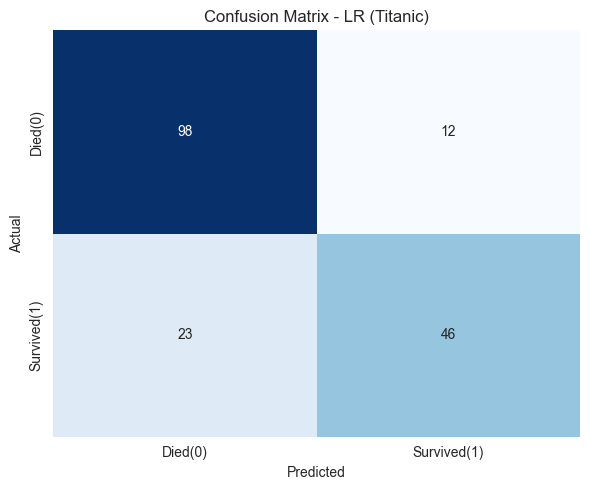

In [37]:
cm_lr = confusion_matrix(y_test, pred_lr)
plot_confusion_matrix(cm_lr, labels=["Died(0)", "Survived(1)"], title="Confusion Matrix - LR (Titanic)")

In [38]:
dt_titanic = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_titanic.fit(X_train, y_train)

pred_dt = dt_titanic.predict(X_test)

print("=== Tugas 4: Decision Tree (Titanic) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, pred_dt):.4f}")
print(f"F1-Score : {f1_score(y_test, pred_dt):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, pred_dt))

=== Tugas 4: Decision Tree (Titanic) ===
Accuracy : 0.7654
Precision: 0.7547
Recall   : 0.5797
F1-Score : 0.6557

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



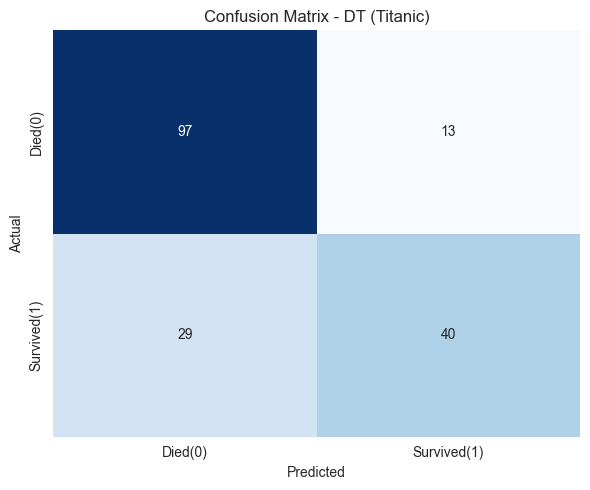

In [39]:
cm_dt = confusion_matrix(y_test, pred_dt)
plot_confusion_matrix(cm_dt, labels=["Died(0)", "Survived(1)"], title="Confusion Matrix - DT (Titanic)")

In [40]:
comparison_titanic = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt)
    ],
    "F1": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt)
    ]
})

comparison_titanic

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.765363,0.754717,0.579710,0.655738


In [41]:
print("=== Interpretasi & Rekomendasi (Titanic) ===")
print("- Logistic Regression cenderung stabil setelah scaling.")
print("- Decision Tree mudah diinterpretasi, tapi rawan overfitting jika depth terlalu besar.")
print("\nRekomendasi improvement:")
print("1) Hyperparameter tuning (GridSearchCV) untuk max_depth, min_samples_leaf.")
print("2) Cross-validation untuk evaluasi lebih robust.")
print("3) Feature engineering: family_size = sibsp + parch + 1, is_alone, title dari nama (jika ada).")
print("4) Coba ensemble: RandomForest atau GradientBoosting untuk performa lebih baik.")

=== Interpretasi & Rekomendasi (Titanic) ===
- Logistic Regression cenderung stabil setelah scaling.
- Decision Tree mudah diinterpretasi, tapi rawan overfitting jika depth terlalu besar.

Rekomendasi improvement:
1) Hyperparameter tuning (GridSearchCV) untuk max_depth, min_samples_leaf.
2) Cross-validation untuk evaluasi lebih robust.
3) Feature engineering: family_size = sibsp + parch + 1, is_alone, title dari nama (jika ada).
4) Coba ensemble: RandomForest atau GradientBoosting untuk performa lebih baik.
